## Chronic Kidney Disease Prediction
**Dataset:** Chronic Kidney Disease (CKD) from Kaggle  
**Link:** https://www.kaggle.com/datasets/mansoordaku/ckdisease  
**Models:** Decision Tree | Naive Bayes | KNN | ANN

## 1: Load and Explore Dataset





In [ ]:
# Load all the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Mount drive
from google.colab import drive
import os
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/kidney_disease.csv'
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("File loaded successfully from Drive!")
    display(df.head())
else:
    print(f"Error : File not found at {file_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File loaded successfully from Drive!


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
# check shape of dataset
print("Shape:",df.shape)

Shape: (400, 26)


In [ ]:
# coloumn names and their datatypes
print(df.dtypes)

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object


In [ ]:
#Statistical summary
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [ ]:
# check missing values
print(df.isnull().sum())

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


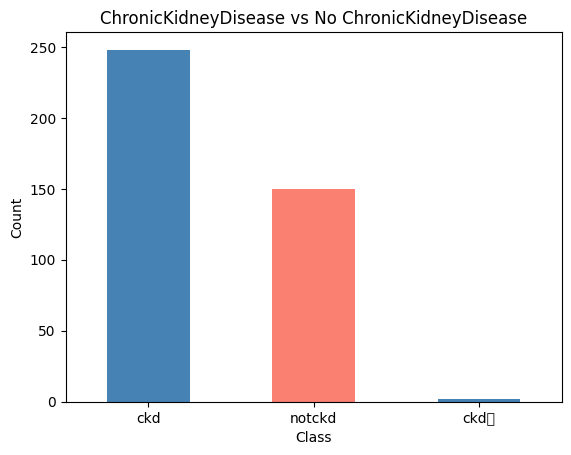

In [ ]:
# Check a specific column disyribution
print(df['classification'].value_counts())
df['classification'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('ChronicKidneyDisease vs No ChronicKidneyDisease')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## 2: Data Processing:
### 2a: clean dirty values

In [ ]:
df.drop('id', axis=1, inplace=True) #id not useful for prediction
df['classification'] = df['classification'].str.strip() #remove whitespace
df = df.replace({'\t?': np.nan, '?': np.nan, ' ': np.nan}) #clean junk value
df = df.replace({'\tyes': 'yes', '\tno': 'no'}) #proper formatting
print("Cleaning done. Shape:", df.shape)

Cleaning done. Shape: (400, 25)


### 2b: Handle Missing Value:

In [ ]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('classification') #remove target from list
print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numerical columns: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']

Categorical columns: ['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [ ]:
# Fill missing values in numerical columns with median
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].median(), inplace=True)
# Fill missing values in categorical columns with mode (most frequent value)
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


### 2c: Label Encoding:

In [ ]:
#converts text to numbers:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Encode all categorical columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
# Encode target column: ckd = 1, notckd = 0
df['classification'] = le.fit_transform(df['classification'])
print("Encoding done.")
df.head()

Encoding done.


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,36.0,1.2,138.0,4.4,15.4,31,71,33,1,2,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,18.0,0.8,138.0,4.4,11.3,25,55,33,0,1,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,53.0,1.8,138.0,4.4,9.6,18,69,33,0,2,0,1,0,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,56.0,3.8,111.0,2.5,11.2,19,61,18,1,1,0,1,1,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,26.0,1.4,138.0,4.4,11.6,22,67,26,0,1,0,0,0,0,0


### 3: Split Dataset into Training and Testing

In [ ]:
from sklearn.model_selection import train_test_split
# Split dataset in features and target variable
X = df.drop('classification', axis=1)# Features
y = df['classification']# Target variable
# Split dataset into training set and test set : 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 320
Testing samples : 80


### 2d: Feature Scaling:


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fit on training data only, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Scaling done.")

Scaling done.


### 4: Train and Test:

Model 1: Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Create Decision Tree classifier object
clf = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
# Train Decision Tree classifier
clf = clf.fit(X_train, y_train)
# Predict the response for test dataset
dt_pred = clf.predict(X_test)
# Model Accuracy, how often is the classifier correct
print("Accuracy:", metrics.accuracy_score(y_test, dt_pred))

Accuracy: 1.0


Model 2: Naiive Bayes Classifier

In [ ]:
from sklearn.naive_bayes import GaussianNB
# Training the model on training set
gnb = GaussianNB()
gnb.fit(X_train, y_train)
# Making predictions on the testing set
nb_pred = gnb.predict(X_test)
# Comparing actual response values (y_test) with predicted response values (nb_pred)
print("Gaussian Naive Bayes model accuracy(in %):", metrics.accuracy_score(y_test, nb_pred)*100)

Gaussian Naive Bayes model accuracy(in %): 98.75


Model 3: K Nearest Neighbours(KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# Training the model with Nearest Neighbors K=5
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(X_train_scaled, y_train)
# Making predictions on our test data
knn_pred = classifier.predict(X_test_scaled)
print("Accuracy:", metrics.accuracy_score(y_test, knn_pred))

Accuracy: 0.9875


Model 4 : Artificial Neural Network (ANN)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# Build ANN model using Keras Sequential API
# Two hidden layers:
network = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,  activation='sigmoid')  # sigmoid for binary classification
])
# Compile the model
network.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])
# Train the network
network.fit(X_train_scaled, y_train, epochs=50, batch_size=16, verbose=0)
# Evaluate on test set
test_loss, test_acc = network.evaluate(X_test_scaled, y_test, verbose=0)
print('test_acc:', test_acc)
# Get predictions — convert probabilities to 0/1 class labels
ann_pred = (network.predict(X_test_scaled) > 0.5).astype(int).flatten()

test_acc: 0.987500011920929
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


## 5: Compare Models

### 5a: Accuracy Comaprison

In [ ]:
models     = ['Decision Tree', 'Naive Bayes', 'KNN', 'ANN']
preds      = [dt_pred, nb_pred, knn_pred, ann_pred]
accuracies = [metrics.accuracy_score(y_test, p)*100 for p in preds]
results_df = pd.DataFrame({'Model': models, 'Accuracy (%)': [round(a, 2) for a in accuracies]})
print(results_df.to_string(index=False))

        Model  Accuracy (%)
Decision Tree        100.00
  Naive Bayes         98.75
          KNN         98.75
          ANN         98.75


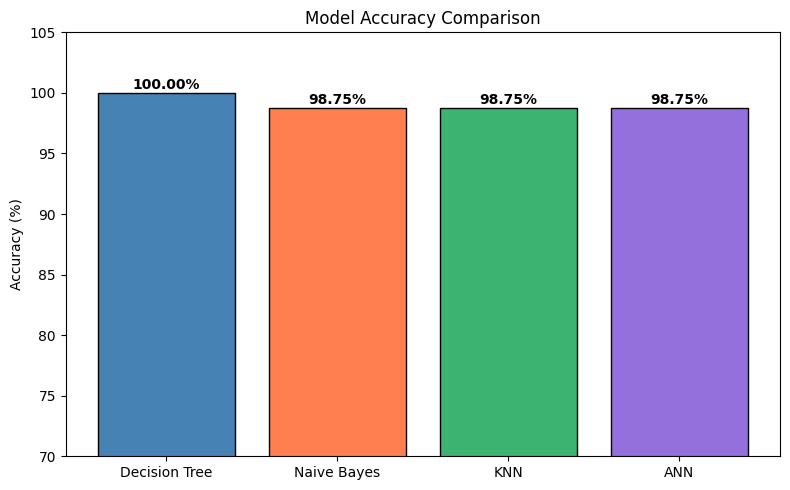

In [ ]:
# Accuracy bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies,
               color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'],
               edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', fontweight='bold')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(70, 105)
plt.tight_layout()
plt.show()

### 5b: Confusion Matrix:

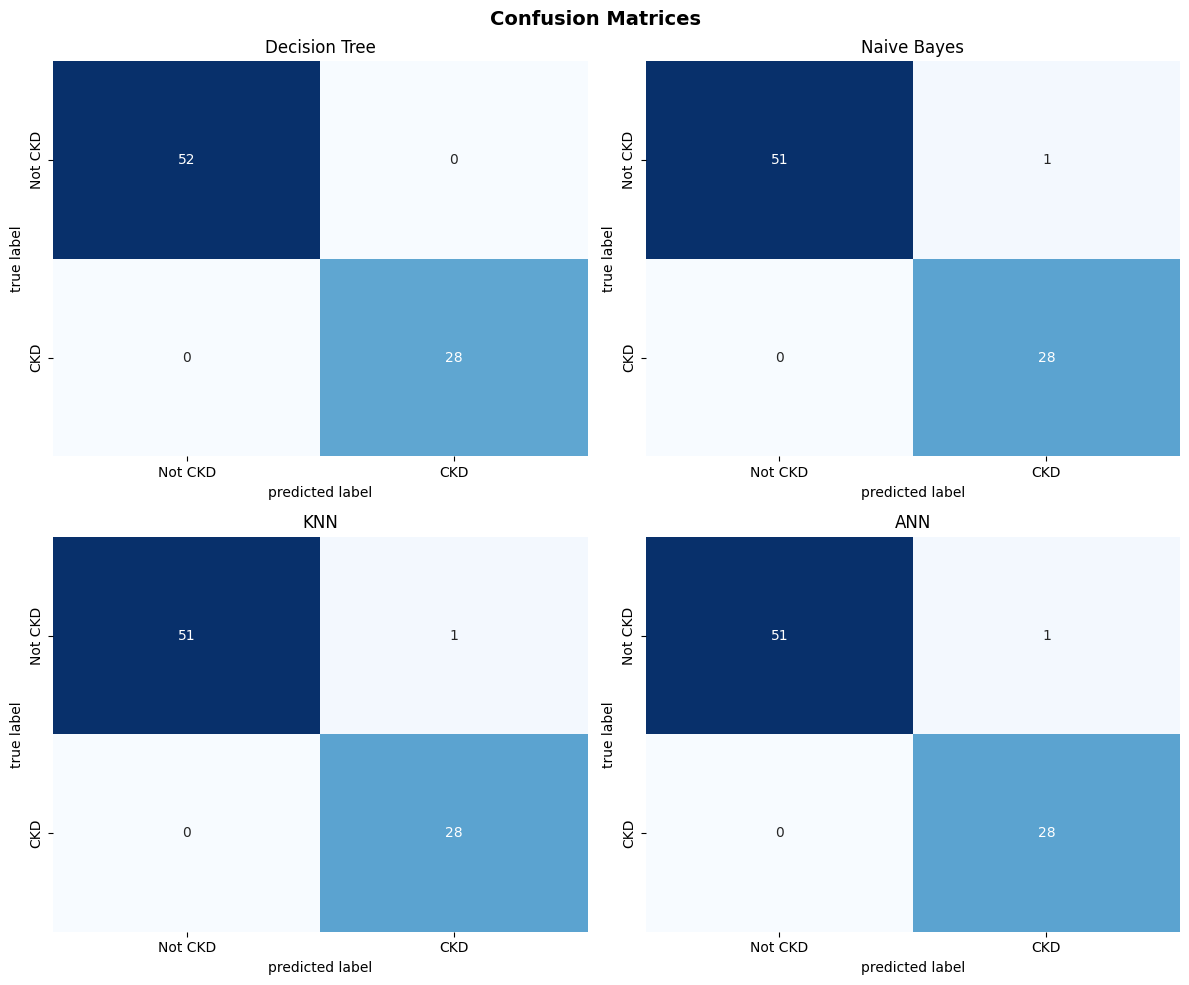

In [ ]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, name, pred in zip(axes.flatten(), models, preds):
    mat = confusion_matrix(y_test, pred)
    sns.heatmap(mat, annot=True, fmt='d', cbar=False, cmap='Blues',
                xticklabels=['Not CKD', 'CKD'],
                yticklabels=['Not CKD', 'CKD'], ax=ax)
    ax.set_xlabel('predicted label')
    ax.set_ylabel('true label')
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 5c: Precision, Recall, F-1 Score

In [ ]:
from sklearn.metrics import classification_report

for name, pred in zip(models, preds):
    print(f"\n{name}")
    print(classification_report(y_test, pred, target_names=['Not CKD', 'CKD']))


Decision Tree
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        52
         CKD       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Naive Bayes
              precision    recall  f1-score   support

     Not CKD       1.00      0.98      0.99        52
         CKD       0.97      1.00      0.98        28

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


KNN
              precision    recall  f1-score   support

     Not CKD       1.00      0.98      0.99        52
         CKD       0.97      1.00      0.98        28

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.

In [ ]:
# Full metrics summary table
from sklearn.metrics import precision_score, recall_score, f1_score
summary = []
for name, pred in zip(models, preds):
    summary.append({
        'Model':     name,
        'Accuracy':  round(metrics.accuracy_score(y_test, pred)*100, 2),
        'Precision': round(precision_score(y_test, pred)*100, 2),
        'Recall':    round(recall_score(y_test, pred)*100, 2),
        'F1-Score':  round(f1_score(y_test, pred)*100, 2)
    })
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

        Model  Accuracy  Precision  Recall  F1-Score
Decision Tree    100.00     100.00   100.0    100.00
  Naive Bayes     98.75      96.55   100.0     98.25
          KNN     98.75      96.55   100.0     98.25
          ANN     98.75      96.55   100.0     98.25


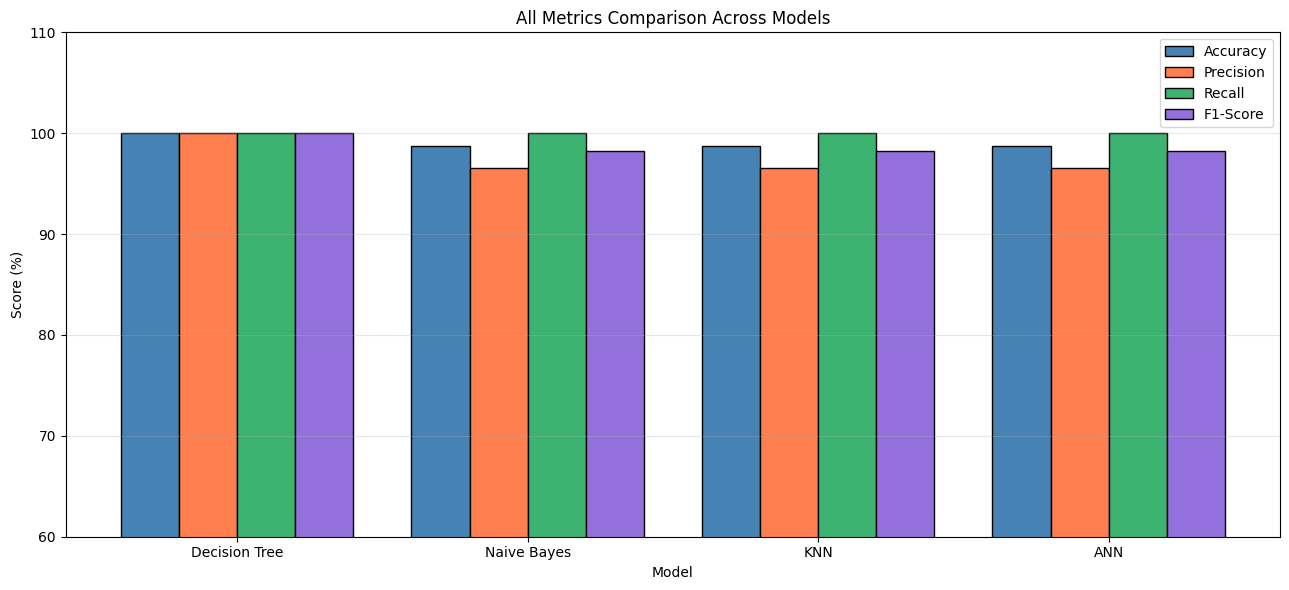

In [ ]:
# All metrics side by side bar chart
x = np.arange(len(models))
width = 0.2
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
metric_values = [
    [metrics.accuracy_score(y_test, p)*100 for p in preds],
    [precision_score(y_test, p)*100        for p in preds],
    [recall_score(y_test, p)*100           for p in preds],
    [f1_score(y_test, p)*100               for p in preds]
]
fig, ax = plt.subplots(figsize=(13, 6))
for i, (mname, mvals, mcolor) in enumerate(zip(metric_names, metric_values, metric_colors)):
    ax.bar(x + i*width, mvals, width, label=mname, color=mcolor, edgecolor='black')
ax.set_xlabel('Model')
ax.set_ylabel('Score (%)')
ax.set_title('All Metrics Comparison Across Models')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(models)
ax.set_ylim(60, 110)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6: Best Performing Model:

In [ ]:
best_index    = accuracies.index(max(accuracies))
best_model    = models[best_index]
best_accuracy = max(accuracies)
print("Best Model :", best_model)
print("Accuracy   :", round(best_accuracy, 2), "%")

Best Model : Decision Tree
Accuracy   : 100.0 %
